In [24]:
from astroquery.mast import Observations
import pandas as pd
from astropy.io import fits
import matplotlib.pyplot as plt
from astropy.visualization import ImageNormalize, LogStretch, SqrtStretch

In [2]:
# A useful list of criteria is provided by the following line
Observations.get_metadata("observations")

Column Name,Column Label,Data Type,Units,Description,Examples/Valid Values
str21,str25,str7,str10,str72,str116
intentType,Observation Type,string,,Whether observation is for science or calibration.,"Valid values: science, calibration"
obs_collection,Mission,string,,Collection,"E.g. SWIFT, PS1, HST, IUE"
provenance_name,Provenance Name,string,,"Provenance name, or source of data","E.g. TASOC, CALSTIS, PS1"
instrument_name,Instrument,string,,Instrument Name,"E.g. WFPC2/WFC, UVOT, STIS/CCD"
project,Project,string,,Processing project,"E.g. HST, HLA, EUVE, hlsp_legus"
filters,Filters,string,,Instrument filters,"F469N, NUV, FUV, LOW DISP, MIRROR"
wavelength_region,Waveband,string,,Energy Band,"EUV, XRAY, OPTICAL"
target_name,Target Name,string,,Target Name,Ex. COMET-67P-CHURYUMOV-GER-UPDATE
target_classification,Target Classification,string,,Type of target,Ex. COMET;COMET BEING ORBITED BY THE ROSETTA SPACECRAFT;SOLAR SYSTEM


In [46]:
# Query the object
obs_table = Observations.query_criteria(obs_id="iaby02x7q")
obs_table

intentType,obs_collection,provenance_name,instrument_name,project,filters,wavelength_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID
str7,str3,str6,str9,str3,str5,str7,str9,str32,str9,float64,float64,str5,str20,int64,float64,float64,float64,float64,float64,str26,float64,str5,str8,int64,str197,str34,str35,str6,bool,float64,str8,str9
science,HST,CALWF3,WFC3/UVIS,HST,F606W,Optical,OMEGA-CEN,STELLAR CLUSTER;GLOBULAR CLUSTER,iaby02x7q,201.6968333333,-47.47956944444,image,"Kim Quijano, Jessica",3,55027.180319444444,55027.1807244213,35.0,474.9,713.2,UVIS Flat Field Uniformity,55083.6666666,11452,SM4/WFC3,--,POLYGON 201.74538088778164 -47.49270371406564 201.68446083598312 -47.51172573013907 201.66850134849096 -47.49176672155571 201.72940403813905 -47.47275316129502 201.74538088778164 -47.49270371406564,mast:HST/product/iaby02x7q_drc.jpg,mast:HST/product/iaby02x7q_drz.fits,PUBLIC,False,nan,23817498,138798314


In [14]:
data = pd.read_csv("../data/WFC3_PSF_2023-06-04T0710.csv", skiprows=4)
data

,id,rootname,filter,aperture,psf_x_center,psf_y_center,chip,psf_flux,sky,qfit,...,focus,dsn_in_wfc3_science,exptime,program_id,ra_targ,dec_targ,sunangle,fgslock,shutrpos,hla_flag
0,9549753,iaby02x7q,F606W,UVIS,1052,1052,2,93636,34.108,0.13899,...,-2.141010,iaby02x7q,35,ABY,201.696833,-47.479569,103.870720,FINE,A,Y
1,9562972,iaby02x7q,F606W,UVIS,1100,1005,1,34869,92.260,0.08746,...,-2.141010,iaby02x7q,35,ABY,201.696833,-47.479569,103.870720,FINE,A,Y
2,9563338,iaby02x7q,F606W,UVIS,1066,1074,1,32935,41.900,0.06784,...,-2.141010,iaby02x7q,35,ABY,201.696833,-47.479569,103.870720,FINE,A,Y
3,9652951,icqx10r2q,F606W,UVIS,1085,1031,2,76149,33.307,0.08380,...,-1.382820,icqx10r2q,40,CQX,201.692833,-47.479056,122.585091,FINE,A,Y
4,9653171,icqx10r2q,F606W,UVIS,1089,1097,2,47487,39.836,0.07524,...,-1.382820,icqx10r2q,40,CQX,201.692833,-47.479056,122.585091,FINE,A,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,19946530,ibc307qyq,F606W,UVIS,1024,1087,2,30839,38.819,0.08005,...,-0.711956,ibc307qyq,40,BC3,201.692833,-47.479056,112.493629,FINE,B,Y
1064,19953694,ibc307qyq,F606W,UVIS,1075,1053,1,58556,44.205,0.06798,...,-0.711956,ibc307qyq,40,BC3,201.692833,-47.479056,112.493629,FINE,B,Y
1065,20087299,idv703skq,F606W,UVIS,1052,1040,2,80646,49.450,0.06450,...,0.351068,idv703skq,60,DV7,201.692833,-47.479056,90.567406,FINE,A,NaN
1066,20087517,idv703skq,F606W,UVIS,1034,1089,2,37814,70.501,0.09214,...,0.351068,idv703skq,60,DV7,201.692833,-47.479056,90.567406,FINE,A,NaN


In [16]:
data.keys()

Index(['id', 'rootname', 'filter', 'aperture', 'psf_x_center', 'psf_y_center',
       'chip', 'psf_flux', 'sky', 'qfit', 'pixc', 'midexp', 'mjd', 'date',
       'focus', 'dsn_in_wfc3_science', 'exptime', 'program_id', 'ra_targ',
       'dec_targ', 'sunangle', 'fgslock', 'shutrpos', 'hla_flag'],
      dtype='object')

In [64]:
# psf = fits.open("../data/MAST_2023-06-04T0316/WFC3PSF/iaby02x7q_9549327_F606W_flc_cutout.fits")
# psf = fits.open("../data/MAST_2023-06-04T0320/WFC3PSF/ib5r02abq_15395781_F606W_flc_cutout.fits")
# psf = fits.open("../data/MAST_2023-06-04T0326/WFC3PSF/ich809nfq_14375272_F606W_flc_cutout.fits")
# psf = fits.open("../data/MAST_2023-06-04T0328/WFC3PSF/ibpk09m5q_9760274_F814W_flc_cutout.fits")
# psf = fits.open("../data/MAST_2023-06-04T0330/WFC3PSF/id1x10d6q_19730748_F606W_flc_cutout.fits")
# psf = fits.open("../data/MAST_2023-06-04T0334/WFC3PSF/ic9r09hsq_4457760_F775W_flc_cutout.fits")
psf = fits.open("../data/MAST_2023-06-04T1024/WFC3PSF/id8001ilq_22939708_F814W_flc_cutout.fits")

In [65]:
psf.info()

Filename: ../data/MAST_2023-06-04T1024/WFC3PSF/id8001ilq_22939708_F814W_flc_cutout.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     217   (21, 21)   float32   


In [66]:
psf[0].data.sum()

553178.2

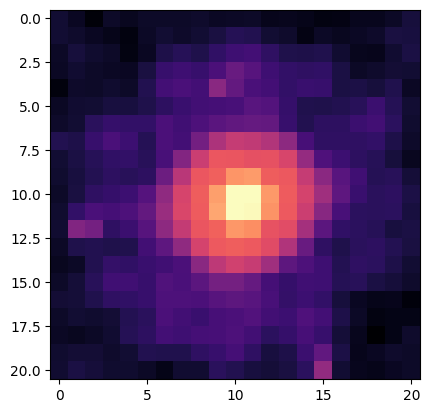

In [67]:
plt.imshow(psf[0].data, cmap="magma", norm=ImageNormalize(stretch=LogStretch()))